In [8]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(scales)
library(ggrepel)
library(patchwork)
library(UpSetR)
library(glue)

In [2]:
## ---- 路径与分析参数 ----
path_seu    <- "/home/data/tanglei/project/prostate_altas/output/04/QC_fin.qs"
path_sketch <- "/home/data/tanglei/project/prostate_altas/output/06/Sketch_Integration_GSE.qs"

label_h3   <- "celltype_manual_H3"
sample_col <- "sample.ID"

options(repr.plot.width = 12, repr.plot.height = 8)

In [3]:
seu <- qs::qread(path_seu)
md_seu <- seu@meta.data
md_seu$cell_id <- colnames(seu)
rm(seu); gc()

seu_sketch <- qs::qread(path_sketch)
md_sk <- seu_sketch@meta.data
md_sk$cell_id <- colnames(seu_sketch)
rm(seu_sketch); gc()

cat("seu:", nrow(md_seu), "| sketch:", nrow(md_sk), "\n")
cat("H3 in seu:", label_h3 %in% colnames(md_seu),
    "| H3 in sketch:", label_h3 %in% colnames(md_sk), "\n")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4011003,214.3,7932185,423.7,5285690,282.3
Vcells,40636203,310.1,4995012175,38109.0,5657955838,43166.8


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4094530,218.7,7932185,423.7,5285690,282.3
Vcells,52743746,402.5,3996009740,30487.2,5657955838,43166.8


seu: 452947 | sketch: 233430 
H3 in seu: TRUE | H3 in sketch: FALSE 


In [4]:
## barcode 对齐：优先用 colnames；若交集偏低则回退到 sample.ID|CB
n_raw <- length(intersect(md_seu$cell_id, md_sk$cell_id))
frac_raw <- n_raw / min(nrow(md_seu), nrow(md_sk))
cat(glue("raw cell_id intersect: {n_raw} ({round(100 * frac_raw, 1)}%)\n"))

use_composite <- FALSE
if (all(c("CB", "sample.ID") %in% colnames(md_seu)) &&
    all(c("CB", "sample.ID") %in% colnames(md_sk))) {
  k_seu <- paste(md_seu$sample.ID, md_seu$CB, sep = "|")
  k_sk  <- paste(md_sk$sample.ID,  md_sk$CB,  sep = "|")
  n_comp <- length(intersect(k_seu, k_sk))
  frac_comp <- n_comp / min(nrow(md_seu), nrow(md_sk))
  cat(glue("sample.ID|CB intersect: {n_comp} ({round(100 * frac_comp, 1)}%)\n"))
  use_composite <- frac_raw < 0.5 && frac_comp > frac_raw
}

if (use_composite) {
  md_seu$key <- k_seu
  md_sk$key  <- k_sk
  cat("-> using key = sample.ID|CB\n")
} else {
  md_seu$key <- md_seu$cell_id
  md_sk$key  <- md_sk$cell_id
  cat("-> using key = cell_id\n")
}

md_seu[[label_h3]] <- as.character(md_seu[[label_h3]])
md_seu$in_sketch <- md_seu$key %in% md_sk$key
cat(glue("intersect cells (H3 transferable): {sum(md_seu$in_sketch)}\n"))

raw cell_id intersect: 157639 (67.5%)sample.ID|CB intersect: 157639 (67.5%)-> using key = cell_id
intersect cells (H3 transferable): 157639

In [5]:
N <- nrow(md_seu)
n_int <- sum(md_seu$in_sketch)
global_rate <- n_int / N

work <- tibble(
  celltype  = md_seu[[label_h3]],
  sample    = as.character(md_seu[[sample_col]]),
  in_sketch = md_seu$in_sketch
)

stat_tbl <- work %>%
  group_by(celltype) %>%
  summarise(
    n_seu         = n(),
    n_kept        = sum(in_sketch),
    n_sample_seu  = n_distinct(sample),
    n_sample_kept = n_distinct(sample[in_sketch]),
    .groups = "drop"
  ) %>%
  mutate(
    retention  = n_kept / n_seu,
    pct_seu    = n_seu / N,
    pct_sketch = n_kept / n_int,
    log2FC     = ifelse(n_kept > 0, log2(pct_sketch / pct_seu), NA_real_),
    lost       = n_kept == 0,
    p_hyper = mapply(function(x, K) {
      lo <- phyper(x,     K, N - K, n_int, lower.tail = TRUE)
      hi <- phyper(x - 1, K, N - K, n_int, lower.tail = FALSE)
      min(1, 2 * min(lo, hi))
    }, n_kept, n_seu)
  ) %>%
  mutate(padj = p.adjust(p_hyper, method = "BH")) %>%
  arrange(desc(n_seu))

per_sample <- work %>%
  group_by(sample, celltype) %>%
  summarise(n_seu = n(), n_kept = sum(in_sketch), .groups = "drop") %>%
  mutate(retention = n_kept / n_seu)

cat("================ 覆盖度 ================\n")
cat(glue("seu: {N} | sketch: {nrow(md_sk)} | intersect: {n_int} ({round(100*global_rate,1)}% of seu)\n"))
cat(glue("H3 subtypes: {nrow(stat_tbl)} | kept in sketch: {sum(!stat_tbl$lost)} | lost: {sum(stat_tbl$lost)}\n"))
if (sum(stat_tbl$lost) == 0) {
  cat("=> seu_sketch 覆盖了 seu 的全部 celltype_manual_H3\n")
} else {
  print(as.data.frame(stat_tbl %>% filter(lost) %>% select(celltype, n_seu)))
}

cat("\n---- 组成占比偏移最大的 10 个亚群 ----\n")
stat_tbl %>%
  arrange(desc(abs(log2FC))) %>%
  select(celltype, n_seu, n_kept, retention, pct_seu, pct_sketch, log2FC, padj) %>%
  head(10) %>% as.data.frame() %>% print()

================ 覆盖度 ================
seu: 452947 | sketch: 233430 | intersect: 157639 (34.8% of seu)H3 subtypes: 53 | kept in sketch: 53 | lost: 0=> seu_sketch 覆盖了 seu 的全部 celltype_manual_H3

---- 组成占比偏移最大的 10 个亚群 ----
                                               celltype n_seu n_kept retention
1       NCAM1+S100B+ classical homeostatic Schwann cell   683    499 0.7306003
2               S100A12+SERPINB2+ inflammatory monocyte  7005   3689 0.5266238
3  IL1A+CCL20+ microenvironment-remodeling hillock cell  1016    236 0.2322835
4                PDPN+CCL21+ lymphatic endothelial cell   294    151 0.5136054
5                      IL6+LIF+ inflammatory fibroblast  6172   1479 0.2396306
6                     LAMP3+CCR7+ mature dendritic cell   319    155 0.4858934
7                 FBLN5+HEY1+ arterial endothelial cell  4105   1993 0.4855055
8                           CCR7+LEF1+ naive CD4 T cell 24343   6106 0.2508319
9                 CDKN1C+FCGR3A+ non-classical monocyte  1205    578 

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


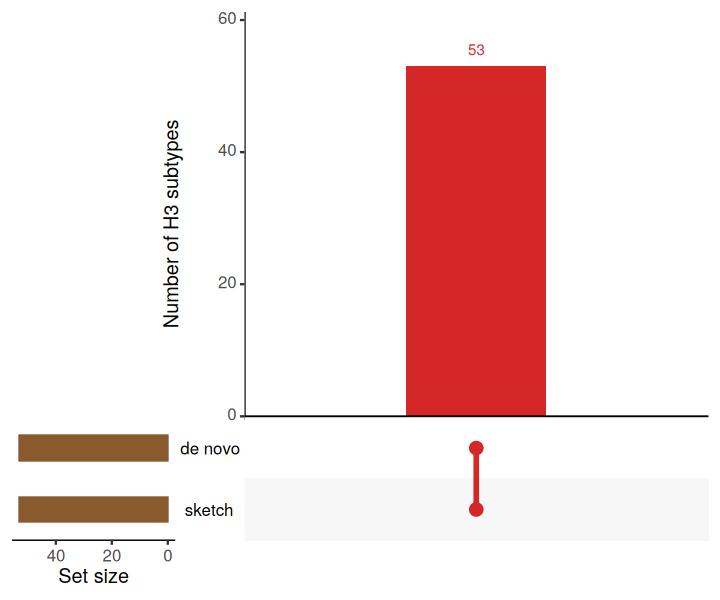

In [6]:
options(repr.plot.width = 6, repr.plot.height = 5)

bar_col <- "#D62728"

upset_ct <- data.frame(
  `de novo` = 1L,
  sketch    = as.integer(!stat_tbl$lost),
  row.names = stat_tbl$celltype,
  check.names = FALSE
)

upset(
  upset_ct,
  sets = c("sketch", "de novo"),
  keep.order = TRUE,
  order.by = "freq",
  mainbar.y.label = "Number of H3 subtypes",
  sets.x.label = "Set size",
  point.size = 3.5, line.size = 1.2,
  text.scale = 1.4,
  main.bar.color = bar_col,
  sets.bar.color = "#8a5a2f",
  matrix.color = bar_col,
  queries = list(
    list(query = intersects,
         params = list("de novo", "sketch"),
         color = bar_col, active = TRUE)
  )
)

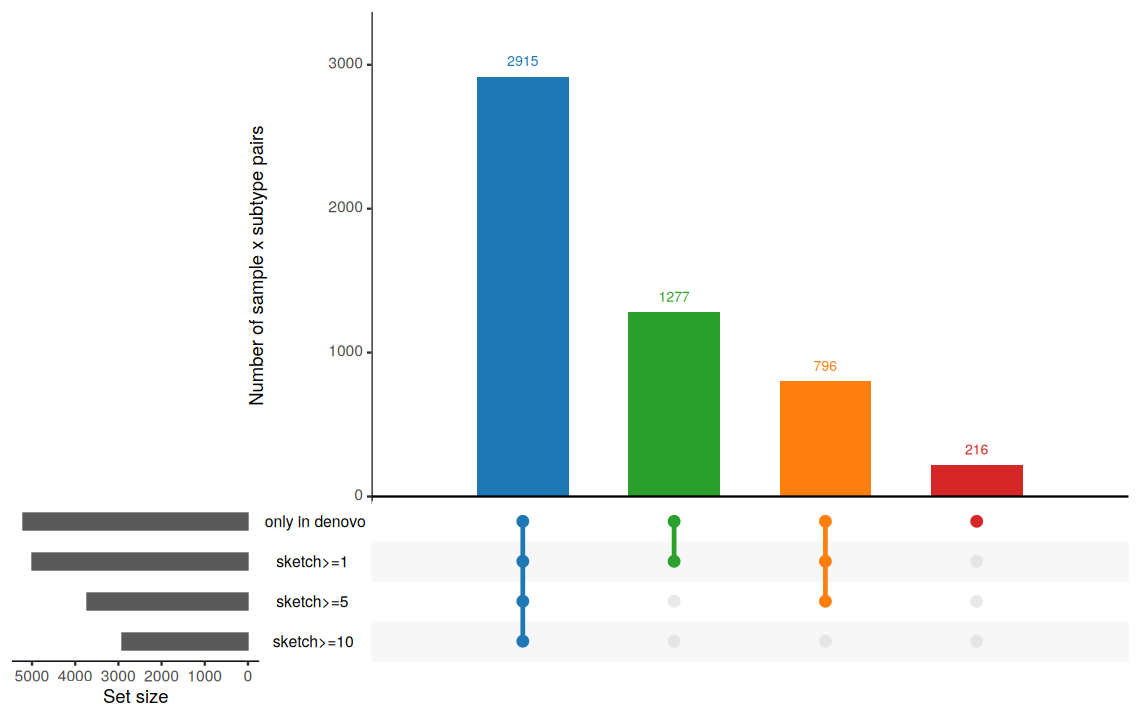

In [10]:
options(repr.plot.width = 9.5, repr.plot.height = 6)

cols <- substr(ggsci::pal_d3()(4), 1, 7)

combo <- per_sample %>%
  filter(n_seu > 0) %>%
  transmute(n_kept = n_kept)

upset_combo <- data.frame(
  `only in denovo` = 1L,
  `sketch>=1`      = as.integer(combo$n_kept >= 1),
  `sketch>=5`      = as.integer(combo$n_kept >= 5),
  `sketch>=10`     = as.integer(combo$n_kept >= 10),
  check.names = FALSE
)

# freq 降序后从左到右：all four | only >=1 | >=5 | only in denovo
bar_cols <- c(cols[1], cols[3], cols[2], cols[4])

upset(
  upset_combo,
  sets = rev(colnames(upset_combo)),
  keep.order = TRUE,
  order.by = "freq",
  nintersects = NA,
  mainbar.y.label = "Number of sample x subtype pairs",
  sets.x.label = "Set size",
  point.size = 3, line.size = 1,
  text.scale = 1.3,
  main.bar.color = bar_cols,
  sets.bar.color = "#595959",
  matrix.color = "grey70",
  queries = list(
    list(query = intersects,
         params = list("only in denovo", "sketch>=1", "sketch>=5", "sketch>=10"),
         color = cols[1], active = TRUE),
    list(query = intersects,
         params = list("only in denovo", "sketch>=1", "sketch>=5"),
         color = cols[2], active = TRUE),
    list(query = intersects,
         params = list("only in denovo", "sketch>=1"),
         color = cols[3], active = TRUE),
    list(query = intersects,
         params = list("only in denovo"),
         color = cols[4], active = TRUE)
  )
)

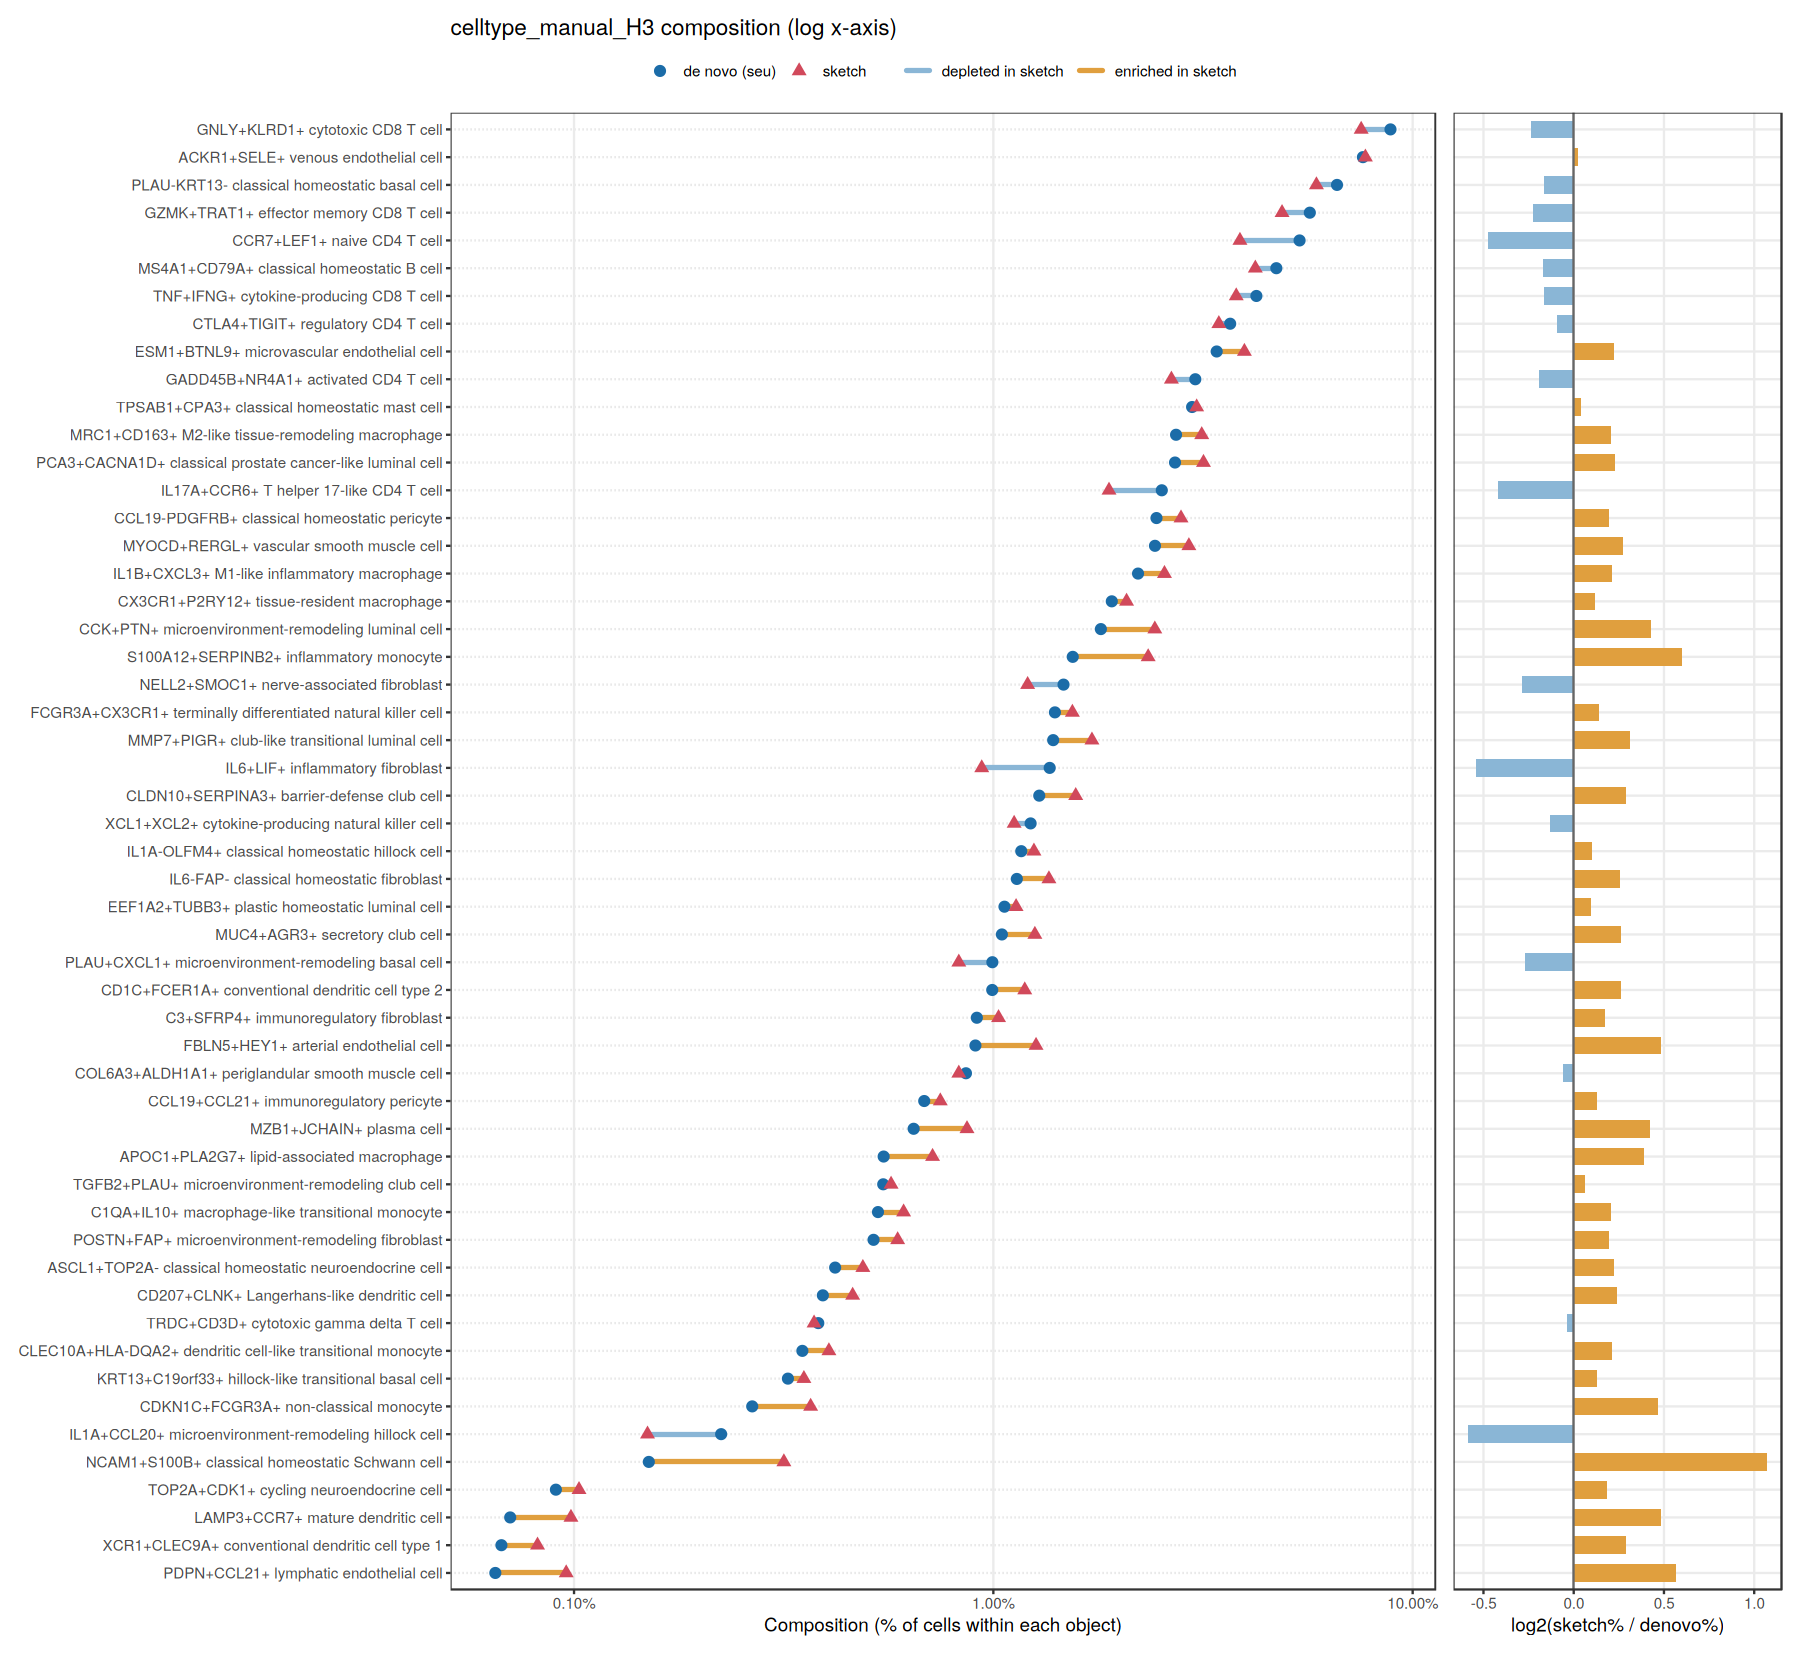

In [11]:
n_ct <- nrow(stat_tbl)
options(repr.plot.width = 15, repr.plot.height = max(6, n_ct * 0.26))

d_db <- stat_tbl %>%
  filter(!lost) %>%
  mutate(
    celltype  = fct_reorder(celltype, pct_seu),
    direction = ifelse(log2FC >= 0, "enriched in sketch", "depleted in sketch")
  )

p_db <- ggplot(d_db, aes(y = celltype)) +
  geom_segment(aes(x = pct_seu, xend = pct_sketch, yend = celltype, color = direction),
               linewidth = 1.1, lineend = "round") +
  geom_point(aes(x = pct_seu, shape = "de novo (seu)"), size = 2.8,
             color = "#1b6ca8", fill = "#1b6ca8") +
  geom_point(aes(x = pct_sketch, shape = "sketch"), size = 2.8,
             color = "#d1495b", fill = "#d1495b") +
  scale_shape_manual(values = c("de novo (seu)" = 16, "sketch" = 17), name = NULL) +
  scale_color_manual(values = c("enriched in sketch" = "#e09f3e",
                                "depleted in sketch" = "#8ab6d6"), name = NULL) +
  scale_x_log10(labels = percent_format(accuracy = 0.01)) +
  labs(x = "Composition (% of cells within each object)", y = NULL,
       title = "celltype_manual_H3 composition (log x-axis)") +
  theme_bw(base_size = 11) +
  theme(panel.grid.major.y = element_line(linetype = "dotted", color = "grey85"),
        panel.grid.minor = element_blank(),
        legend.position = "top")

p_fc <- ggplot(d_db, aes(x = log2FC, y = celltype, fill = log2FC > 0)) +
  geom_col(width = 0.6) +
  geom_vline(xintercept = 0, color = "grey40") +
  scale_fill_manual(values = c("TRUE" = "#e09f3e", "FALSE" = "#8ab6d6"), guide = "none") +
  labs(x = "log2(sketch% / denovo%)", y = NULL) +
  theme_bw(base_size = 11) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        panel.grid.minor = element_blank())

p_db + p_fc + plot_layout(widths = c(3, 1))

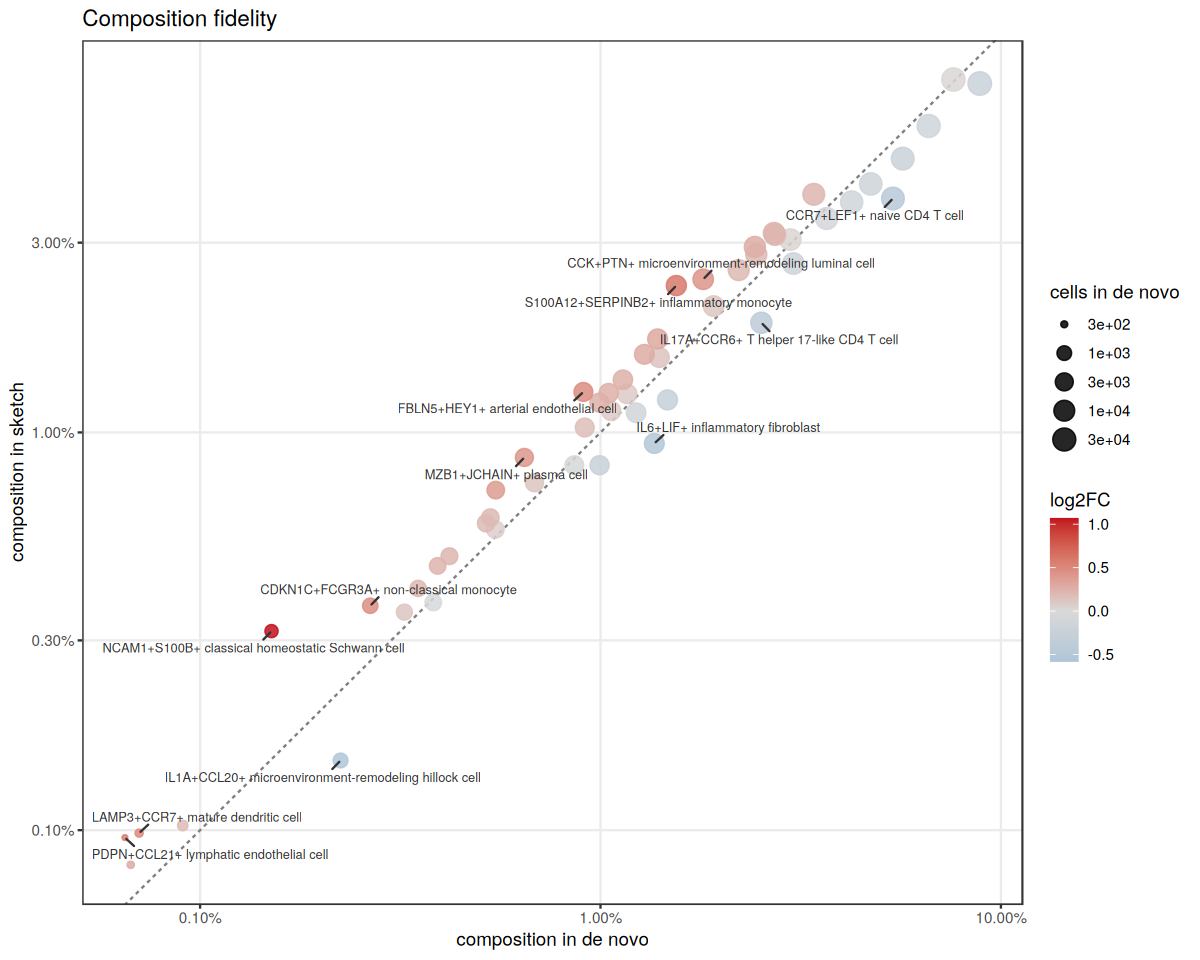

In [13]:
options(repr.plot.width = 10, repr.plot.height = 8)

d_fid <- stat_tbl %>% filter(!lost) %>% mutate(dev = abs(log2FC))
lab_fid <- d_fid %>% arrange(desc(dev)) %>% slice_head(n = 12)

ggplot(d_fid, aes(x = pct_seu, y = pct_sketch)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  geom_point(aes(size = n_seu, color = log2FC), alpha = 0.85) +
  geom_text_repel(data = lab_fid, aes(label = celltype), size = 2.6,
                  max.overlaps = 30, min.segment.length = 0,
                  box.padding = 0.4, color = "grey20") +
  scale_x_log10(labels = percent_format(accuracy = 0.01)) +
  scale_y_log10(labels = percent_format(accuracy = 0.01)) +
  scale_color_gradient2(low = "#8ab6d6", mid = "grey85", high = "#c1121f",
                        midpoint = 0, name = "log2FC") +
  scale_size_continuous(trans = "log10", name = "cells in de novo") +
  labs(x = "composition in de novo", y = "composition in sketch",
       title = "Composition fidelity") +
  theme_bw(base_size = 11) +
  theme(panel.grid.minor = element_blank())

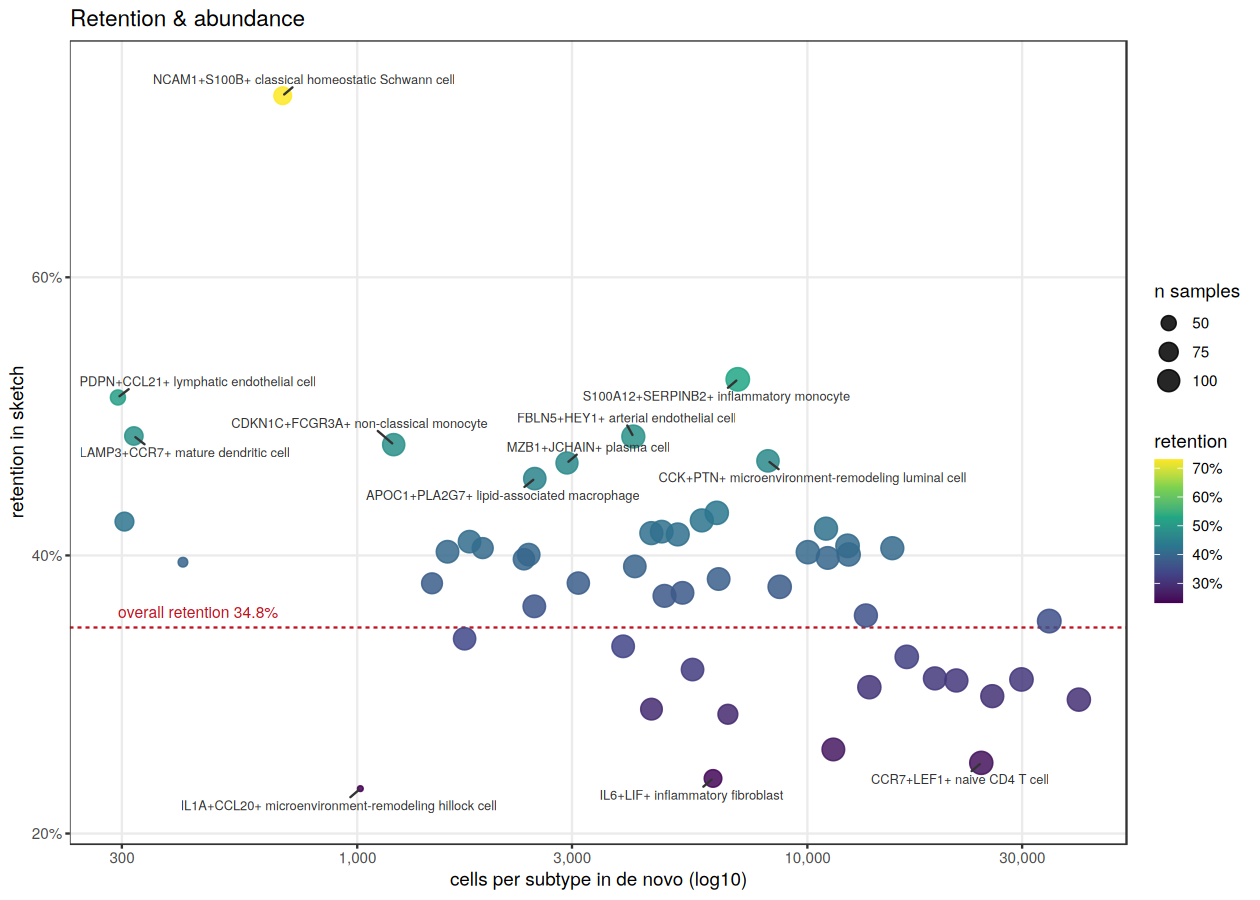

In [14]:
options(repr.plot.width = 10.5, repr.plot.height = 7.5)

d_ret <- stat_tbl %>% mutate(dev = abs(retention - global_rate))
lab_ret <- d_ret %>% arrange(desc(dev)) %>% slice_head(n = 12)

ggplot(d_ret, aes(x = n_seu, y = retention)) +
  geom_hline(yintercept = global_rate, linetype = "dashed", color = "#c1121f") +
  annotate("text", x = min(d_ret$n_seu), y = global_rate, hjust = 0, vjust = -0.8,
           label = sprintf("overall retention %.1f%%", 100 * global_rate),
           size = 3.2, color = "#c1121f") +
  geom_point(aes(size = n_sample_seu, color = retention), alpha = 0.85) +
  geom_text_repel(data = lab_ret, aes(label = celltype), size = 2.6,
                  max.overlaps = 30, min.segment.length = 0,
                  box.padding = 0.4, color = "grey20") +
  scale_x_log10(labels = label_number(big.mark = ",")) +
  scale_y_continuous(labels = percent_format(accuracy = 1),
                     expand = expansion(mult = 0.08)) +
  scale_color_viridis_c(option = "D", labels = percent_format(accuracy = 1),
                        name = "retention") +
  scale_size_continuous(name = "n samples") +
  labs(x = "cells per subtype in de novo (log10)", y = "retention in sketch",
       title = "Retention & abundance") +
  theme_bw(base_size = 11) +
  theme(panel.grid.minor = element_blank())